In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from tqdm import tqdm
from patsy import dmatrix
from scipy.spatial import distance
from statsmodels.stats.outliers_influence import summary_table
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split

In [2]:
wages = pd.read_csv(r"D:\ML&Fintech\data_ML&Fintech\Wage.csv")
wages.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [3]:
X_train, X_test, y_train, y_test = train_test_split(wages.age, wages.wage, test_size=0.4, random_state=1)

In [4]:
# Cross-validation method
MSEs = []

for i in np.arange(1, 8):
    poly = PolynomialFeatures(degree=i)
    lm = LinearRegression(fit_intercept=False)
    
    X_poly = poly.fit_transform(X_train.values.reshape(-1, 1))
    lm.fit(X_poly, y_train)
    
    pred = lm.predict(poly.transform(X_test.values.reshape(-1, 1)))
    MSEs.append(mean_squared_error(y_test, pred))

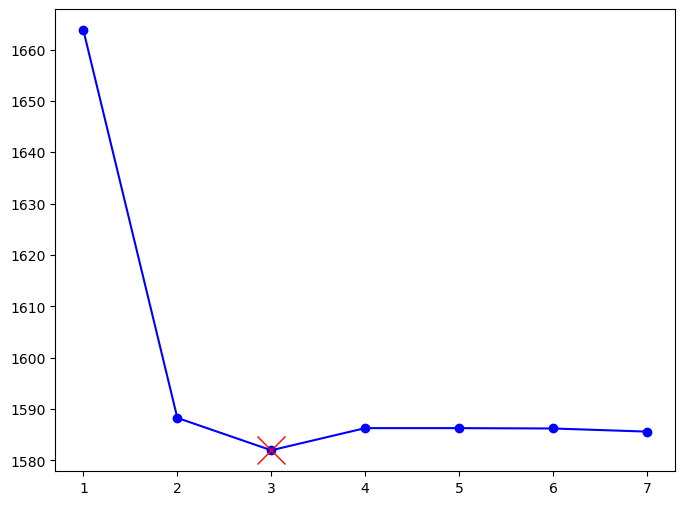

In [5]:
min_mse_idx, min_mse = np.argmin(MSEs), np.min(MSEs)

fig, axes = plt.subplots(1,1, figsize=(8,6))
axes.plot(np.arange(1,8), MSEs, color='b', marker='o')
axes.plot(min_mse_idx+1, min_mse, color='r', marker='x', markersize=20)

In [6]:
df = pd.concat([wages.wage, wages.age], axis=1)

for i in range(2, 8):
    df[f'age{i}'] = np.power(df.age, i)

df.head(2)

,wage,age,age2,age3,age4,age5,age6,age7
0,75.043154,18,324,5832,104976,1889568,34012224,612220032
1,70.476020,24,576,13824,331776,7962624,191102976,4586471424


In [7]:
# Hypothesis Testing using ANOVA

models = []

for i in range(1, 8):
    formula = '+'.join(df.iloc[:, 1:i+1].columns)
    formula = 'wage ~ '+formula
    
    fit = smf.ols(formula, data=df).fit()
    models.append(fit)
    
table = sm.stats.anova_lm(models[0], models[1], models[2], models[3], models[4], models[5], models[6])
table

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.717559,2.226664e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.897326,1.671425e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.813115,5.094581e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.805674,3.694747e-01
5,2993.0,4.766389e+06,1.0,3932.257485,2.470144,1.161330e-01
6,2993.0,4.764599e+06,-0.0,1790.501734,-inf,NaN


In [8]:
# Fit a Step Function to predict wage using age

step_MSEs = []

for i in np.arange(2, 20):
    age_step = pd.cut(wages.age, i, right=True)
    
    # Create dummy variable for the age steps
    age_step_dummies = pd.get_dummies(age_step)
    
    # Drop one of the columns of dummy table
    age_step_dummies = age_step_dummies.drop(age_step_dummies.columns[1], axis=1)
    
    step_MSEs.append(-np.mean(cross_val_score(LinearRegression(fit_intercept=True), age_step_dummies, wages.wage,
                                        cv=5, scoring='neg_mean_squared_error')))

step_MSEs    

[np.float64(1732.6986596047313),
 np.float64(1683.698474177588),
 np.float64(1635.0521500980217),
 np.float64(1633.1637011392963),
 np.float64(1625.28752203855),
 np.float64(1613.0891732102846),
 np.float64(1601.7335509459078),
 np.float64(1614.0171369089444),
 np.float64(1608.1745080268333),
 np.float64(1604.9640272464535),
 np.float64(1605.4403007974029),
 np.float64(1601.4991935521182),
 np.float64(1608.1377001125763),
 np.float64(1607.6207186954489),
 np.float64(1599.0182764015954),
 np.float64(1609.2959898835668),
 np.float64(1606.3409051453968),
 np.float64(1608.6903498018382)]

Text(0, 0.5, 'CV MSE')

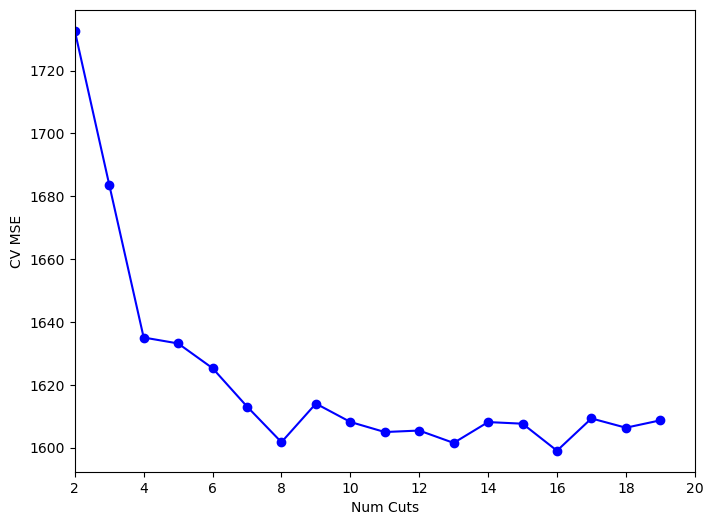

In [9]:
min_mse_idx, min_mse = np.argmin(step_MSEs), np.min(step_MSEs)

fig, axes = plt.subplots(1,1, figsize=(8,6))
axes.plot(np.arange(2,20), np.array(step_MSEs), color='b', marker='o')
axes.set_xlim([2,20]);

axes.set_xlabel('Num Cuts')
axes.set_ylabel('CV MSE')

In [10]:
# Fit a step function using 8 cuts

age_step, bins = pd.cut(wages.age, 8, retbins=True, right=True)
age_step.value_counts(sort=False)

age
(17.938, 25.75]    231
(25.75, 33.5]      519
(33.5, 41.25]      671
(41.25, 49.0]      728
(49.0, 56.75]      503
(56.75, 64.5]      276
(64.5, 72.25]       54
(72.25, 80.0]       18
Name: count, dtype: int64

In [17]:
age_step_dummies = pd.get_dummies(age_step)
age_step_dummies = age_step_dummies.drop(age_step_dummies.columns[0], axis=1)

age_step_dummies = sm.add_constant(age_step_dummies)

y = wages['wage'].astype(float).values
X = age_step_dummies.astype(float).values
X = sm.add_constant(X, has_constant='add')

fit = sm.OLS(y, X).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     39.54
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           1.85e-53
Time:                        07:30:26   Log-Likelihood:                -15317.
No. Observations:                3000   AIC:                         3.065e+04
Df Residuals:                    2992   BIC:                         3.070e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.1409      1.315     29.007      0.0

In [12]:
agelims = np.arange(wages.age.min(), wages.age.max())
age_step_bins = np.digitize(agelims.ravel(), bins)
X_test = pd.get_dummies(age_step_bins).drop(1, axis=1)

In [13]:
# Confidence Intervals
simple_table, data, columns = summary_table(fit, alpha=0.05)
mean_ci_low, mean_ci_upp = data[:, 4:6].T